# ECG Chagas Project

Load and clean data, basic EDA, split the data by patient, prepare the features, run baseline model, and save files for the next models.


## Imports


In [9]:
%pip install kagglehub -q

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score, ConfusionMatrixDisplay


You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


## Load the data


In [10]:
path = kagglehub.dataset_download(
    "matteofasuloo/code15-ecg-chagas-balanced"
)

files = glob.glob(path + "/**/*.csv", recursive=True)

features_file = [f for f in files if f.endswith("signals_features.csv")][0]
labels_file = [f for f in files if f.endswith("code15_chagas_labels.csv")][0]

features = pd.read_csv(features_file)
labels = pd.read_csv(labels_file)

print("Features shape:", features.shape)
print("Labels shape:", labels.shape)

features.head()


Features shape: (13092, 51)
Labels shape: (343424, 3)


,exam_id,P_wave_duration_mean,P_wave_duration_std,P_wave_duration_min,P_wave_duration_max,PR_interval_mean,PR_interval_std,PR_interval_min,PR_interval_max,PR_segment_mean,...,HRV_Prc80NN,HRV_pNN50,HRV_pNN20,HRV_MinNN,HRV_MaxNN,HRV_HTI,HRV_TINN,age,is_male,chagas
0,2912406,36.250000,10.856203,17.5,47.5,137.812500,39.830836,110.0,222.5,101.562500,...,1110.0,55.555556,66.666667,865.0,1135.0,4.500000,250.0000,55,False,False
1,158912,44.285714,4.498677,37.5,52.5,87.857143,0.944911,87.5,90.0,43.571429,...,735.0,0.000000,12.500000,710.0,740.0,2.666667,0.0000,38,False,False
2,3785113,66.590909,5.156637,60.0,75.0,86.818182,8.069302,72.5,95.0,20.227273,...,781.0,0.000000,8.333333,735.0,792.5,6.000000,23.4375,48,False,False
3,235009,23.333333,7.180703,15.0,40.0,146.944444,16.619726,127.5,182.5,123.611111,...,787.0,25.000000,66.666667,640.0,822.5,4.000000,148.4375,33,False,False
4,881906,65.000000,25.248762,35.0,92.5,128.125000,68.446299,82.5,230.0,63.125000,...,800.0,0.000000,16.666667,737.5,805.0,3.000000,46.8750,81,False,False


The feature file contains the ECG measurements for 13,092 exams. The larger label file contains the Chagas result and patient ID, which is used when combining the data.


## Combine and clean the data


In [11]:
labels = labels[["exam_id", "patient_id", "chagas"]]
labels = labels.rename(columns={"chagas": "label_check"})

data = features.merge(labels, on="exam_id")

print("Labels match:",
      (data["chagas"] == data["label_check"]).mean())

data = data.drop(columns="label_check")
data = data.rename(columns={"chagas": "target"})

data = data.drop_duplicates(subset="exam_id")
data = data.replace([np.inf, -np.inf], np.nan)
data = data.dropna(subset=["target"])

data["target"] = data["target"].astype(int)
data["is_male"] = data["is_male"].astype(int)

print("Rows after cleaning:", len(data))
print("Missing feature values:", data.isna().sum().sum())


Labels match: 1.0
Rows after cleaning: 13092
Missing feature values: 2467


Merged the files using `exam_id` and checked that the two Chagas label columns matched. After removing duplicate exam IDs, there were still 13092 exams. There were 2467 missing feature values, so I will handle those later instead of dropping a lot of rows.


## Check for conflicting patient labels


In [12]:
# Find patients who have both a positive and negative label
patient_label_counts = data.groupby("patient_id")["target"].nunique()

conflicting_patients = patient_label_counts[
    patient_label_counts > 1
].index

print("Patients with conflicting labels:", len(conflicting_patients))

# Remove all exams from those patients
exams_removed = data["patient_id"].isin(conflicting_patients).sum()
data = data[
    ~data["patient_id"].isin(conflicting_patients)
].copy()

print("Exams removed:", exams_removed)
print("Rows left:", len(data))

# Confirm that the remaining patients have one label each
conflicts_left = (
    data.groupby("patient_id")["target"].nunique() > 1
).sum()

print("Conflicting patients left:", conflicts_left)


Patients with conflicting labels: 66
Exams removed: 161
Rows left: 12931
Conflicting patients left: 0


I found 66 patients who had both positive and negative labels across different exams. Since the patient split needs one consistent label per person, I removed all exams from those patients. The remaining patients each have one target label.


## Basic EDA


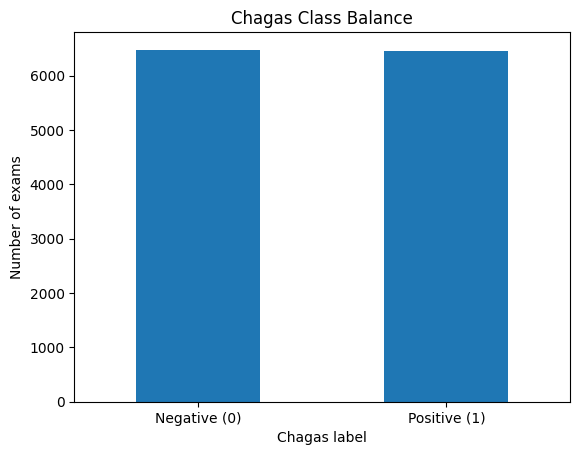

target
0    6475
1    6456
Name: count, dtype: int64


In [13]:
class_counts = data["target"].value_counts().sort_index()

class_counts.plot(kind="bar")

plt.xticks([0, 1], ["Negative (0)", "Positive (1)"], rotation=0)
plt.xlabel("Chagas label")
plt.ylabel("Number of exams")
plt.title("Chagas Class Balance")
plt.show()

print(class_counts)


The two classes are almost the same size. 

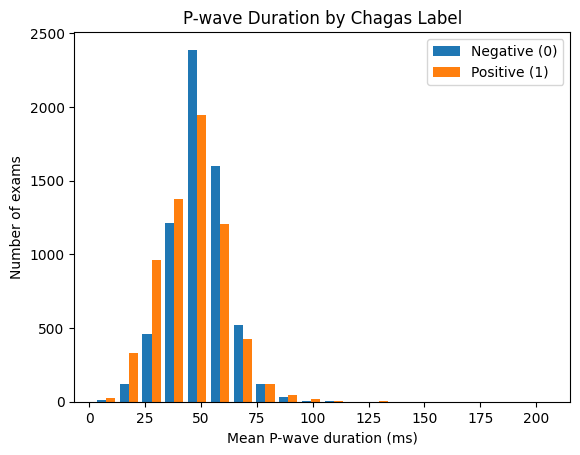

Negative mean: 49.4
Positive mean: 45.78


In [14]:
feature = "P_wave_duration_mean"

negative = data[data["target"] == 0][feature].dropna()
positive = data[data["target"] == 1][feature].dropna()

plt.hist(
    [negative, positive],
    bins=20,
    label=["Negative (0)", "Positive (1)"]
)

plt.xlabel("Mean P-wave duration (ms)")
plt.ylabel("Number of exams")
plt.title("P-wave Duration by Chagas Label")
plt.legend()
plt.show()

print("Negative mean:", round(negative.mean(), 2))
print("Positive mean:", round(positive.mean(), 2))


The side by side bars make it easier to compare the two groups. Their P-wave duration distributions still overlap a lot, so this feature by itself probably will not be enough to classify Chagas.


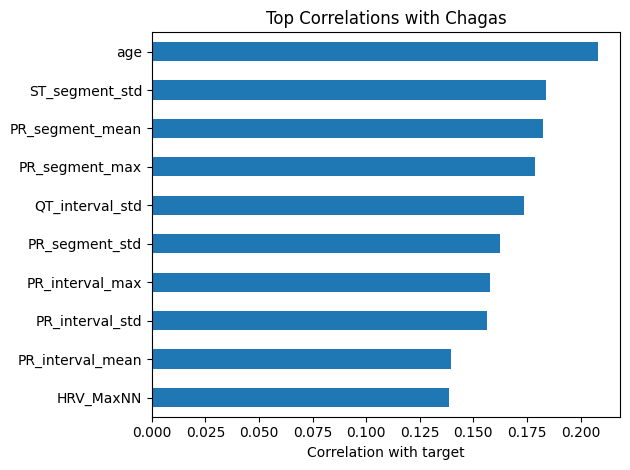

In [15]:
corr = data.drop(columns=["exam_id", "patient_id"]).corr(
    numeric_only=True
)["target"].drop("target")

top_names = corr.abs().sort_values(ascending=False).head(10).index
top_corr = corr.loc[top_names].sort_values()

top_corr.plot(kind="barh")

plt.xlabel("Correlation with target")
plt.title("Top Correlations with Chagas")
plt.tight_layout()
plt.show()


Age had the largest correlation with the target. Several PR, ST, and QT measurements also appeared in the top ten, but none of the correlations were very strong, so the models will need to use several features.


## Split the data by patient


In [16]:
# Keep one target value for each patient
patient_data = data[["patient_id", "target"]].drop_duplicates(
    subset="patient_id"
)

# Split patients into 60% train and 40% temporary
train_patients, temp_patients = train_test_split(
    patient_data,
    test_size=0.40,
    random_state=42,
    stratify=patient_data["target"]
)

# Split the remaining patients into validation and test
val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=0.50,
    random_state=42,
    stratify=temp_patients["target"]
)

train_data = data[data["patient_id"].isin(train_patients["patient_id"])]
val_data = data[data["patient_id"].isin(val_patients["patient_id"])]
test_data = data[data["patient_id"].isin(test_patients["patient_id"])]

X_train = train_data.drop(columns=["target", "exam_id", "patient_id"])
y_train = train_data["target"]

X_val = val_data.drop(columns=["target", "exam_id", "patient_id"])
y_val = val_data["target"]

X_test = test_data.drop(columns=["target", "exam_id", "patient_id"])
y_test = test_data["target"]

print("Train exams:", len(X_train))
print("Validation exams:", len(X_val))
print("Test exams:", len(X_test))

print("Train positive rate:", round(y_train.mean(), 3))
print("Validation positive rate:", round(y_val.mean(), 3))
print("Test positive rate:", round(y_test.mean(), 3))


Train exams: 7746
Validation exams: 2584
Test exams: 2601
Train positive rate: 0.498
Validation positive rate: 0.5
Test positive rate: 0.501


I split by `patient_id` instead of randomly splitting individual exams. This keeps all exams from the same patient in one set. The exam totals are not exactly 60/20/20, but the patients are split close to those percentages and the class balance should stay similar.


## Prepare the features


In [17]:
imputer = SimpleImputer(strategy="median")

X_train_ready = imputer.fit_transform(X_train)
X_val_ready = imputer.transform(X_val)
X_test_ready = imputer.transform(X_test)

scaler = StandardScaler()

X_train_ready = scaler.fit_transform(X_train_ready)
X_val_ready = scaler.transform(X_val_ready)
X_test_ready = scaler.transform(X_test_ready)


I filled missing values using the median from the training set. I then standardized the features because measurements such as age, ECG intervals, and HRV use different ranges. The validation and test data only use values learned from the training set.


## Baseline model


Accuracy: 0.5
Precision: 0.0
Recall: 0.0
F1 score: 0.0
ROC-AUC: 0.5


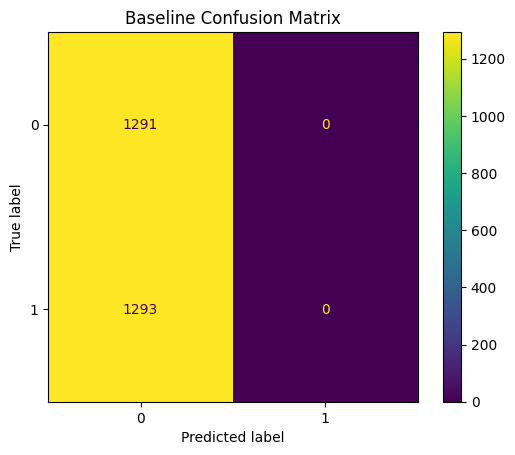

In [18]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train_ready, y_train)

pred = baseline.predict(X_val_ready)
prob = baseline.predict_proba(X_val_ready)[:, 1]

print("Accuracy:", round(accuracy_score(y_val, pred), 3))
print("Precision:", round(precision_score(y_val, pred, zero_division=0), 3))
print("Recall:", round(recall_score(y_val, pred, zero_division=0), 3))
print("F1 score:", round(f1_score(y_val, pred, zero_division=0), 3))
print("ROC-AUC:", round(roc_auc_score(y_val, prob), 3))

ConfusionMatrixDisplay.from_predictions(y_val, pred)
plt.title("Baseline Confusion Matrix")
plt.show()


The baseline does not use any ECG features. It predicts the most common training class for every validation exam. It got about 50% accuracy but missed every positive case, so it is only a starting benchmark. The logistic regression and tree models should perform better and correctly predict both classes.


In [19]:
os.makedirs("processed_data", exist_ok=True)

train = pd.DataFrame(X_train_ready, columns=X_train.columns)
validation = pd.DataFrame(X_val_ready, columns=X_train.columns)
test = pd.DataFrame(X_test_ready, columns=X_train.columns)

train["target"] = y_train.reset_index(drop=True)
validation["target"] = y_val.reset_index(drop=True)
test["target"] = y_test.reset_index(drop=True)

train.to_csv("processed_data/train.csv", index=False)
validation.to_csv("processed_data/validation.csv", index=False)
test.to_csv("processed_data/test.csv", index=False)

print("Processed files saved")


Processed files saved


These CSV files use the cleaned patient-level split and the same preprocessing. The training and validation files can be used for the next models. The test file should be left alone until the final model is chosen.


## What still needs to be done

- Check the outliers and decide if any should be removed.
- Work on logistic regression.
- Work on the decision tree and random forest.
- Compare the validation results and choose the best model.
- Test the final model once we decide which one is best.
